# Clasificación de la calidad del instancias de vino
En este ejercicio se intenta entrenar un clasificador para predecir la calidad de un conjunto de vinos de la [marca portuguesa "Vinho verde"](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset) utilizando datos sobre componentes químicos presentes en cada instancia. Se utiliza en enfoque de clasificación multiclase, utilizando algunos enfoques como técnicas de sobremuestreo de datos, feature engineering para detectar un posible subconjunto de atributos que pueda derivar en clasificadores con un desempeño superior.

# Paquete de Intel para mejorar el rendimiento
La librería `scikit-learn-intelex` es una extensión que otorga reducciones significativas de tiempo en algunas funciones y modelos de Scikit reemplazando la implementación original por una que utiliza instrucciones vectoriales del procesador de forma nativa para realizar algunos calculos. La biblioteca es compatible con elementos de Scikit como: `RandomForestClassifier`, `SVC`, `train_tes_split`, `roc_auc_score`, `KNearestClassifier`, etc. Solo funciona en entorno de ejecucicón que utilicen procesadores **Intel**.

**Nota**: En algunas técnicas como bosques aleatorios esta implementación impone restricciones sobre valores que pueden tomar algunos hiperparámetros como `min_samples_split` en `RandomForestClassifier`.

In [1]:
from sklearnex import patch_sklearn

patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Carga de datos
Se cargan los datos desde el archivo original y se elimina la columna 'Id' que no aporta información significativa para el análisis.

In [2]:
from pandas import read_csv, DataFrame, concat

RUTA = "/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv"

datos = read_csv(RUTA)
datos.drop(columns=["Id"], inplace=True)

# Verificando el contenido de los archivos
Como podemos observar en la celda, este conjunto de datos consta de 1142 instancias y 12 campos. En su mayoría contiene variables cuantitativas, además de caracterizarse por no tener valores nulos.

In [15]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [16]:
datos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Análisis de datos
## Variables cuantitativas
### Medidas de tendencia central
En general las variables muestran rangos de valores e intercuartilícios bastante amplios con rangos. En la mayoría, la media y la mediana son bastante cercanas. Gran parte de estos concentra los valores atípicos a la derecha de la media y una minoría a ambos lados de la media. Solo la variable "density" muestra el comportamiento contrario, un rango de valores pequeño que tiende a la simetría.

### Medidas de dispersión
En general observamos datos heterogeneos en la mayoría de los casos, con alta dispersión respecto a la media. Solo en los campos "pH", "density", "alcohol" y "quality" tienen una distribución homogenea. Siendo los campos "sulphates" y "fixed acidity" los que tienen un nivel de dispersión moderada.  

### Distribución de los campos y forma de curva
#### Asimetría
Los coeficientes de simetría de las variables "pH", "density" y "citric acid" tienden a la simetría. El atributo "volatile acidity" muestra una asimetría positiva moderada. El resto son asimétricos positivos, dónde sus valores están en al cola derecha de la curva (a la derecha de la media).  

#### Cúrtosis
La cúrtosis nos indica que ninguna de las distribuciones es cercana a la distribución normal (mesocúrticas, el coef. es igual a 3). Las curvas que son leptocúrticas (coef. mayor que 3) corresponden a los atributos "residual sugar", "chlorides", "total sulfur dioxide", "sulphates" lo cual indica alta probabilidad de valores atipícos y valores lejanos a la media. Finalmente los campos "acidity", "citric acid", "volatile acidity", "free sulfur dioxide", "density", "pH" y "alcohol" tiene curvas platicúrticas (coef. menor que 3), indicandonos lo contrario a los otros atributos. 

In [5]:
medidas = datos.drop(columns=["quality"]).describe()
curtosis = datos.drop(columns=["quality"]).kurtosis()
asimetria = datos.drop(columns=["quality"]).skew()

forma_curva = concat([curtosis, asimetria], axis=1).rename(columns={0: "Curtosis", 1: "Coef. simetría"}).transpose()
coef_var = ((medidas.loc["std",:] / medidas.loc["mean", :]) *100).to_frame(name="Coef. variación (%)").transpose()

concat([medidas, forma_curva, coef_var])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000
Curtosis,1.384614,1.375531,-0.714686,27.675366,47.078324,1.932170,5.098748,0.888123,0.925791,12.017377,0.221179
Coef. simetría,1.044930,0.681547,0.371561,4.361096,6.026360,1.231261,1.665766,0.102395,0.221138,2.497266,0.863313


Vemos una tendencia ascendente en cuanto al ácido citríco y la cantidad fija de ácido del vino. Es una relación esperable dado que ambas describen el nivel de acidez del vino. También observamos que a medida que ambos niveles de acidez aumentan el pH disminuye, esto va acorde a la definición del pH.

<Axes: title={'center': "'citric acid' frente a 'fixed acidity' según 'pH'"}, xlabel='citric acid', ylabel='fixed acidity'>

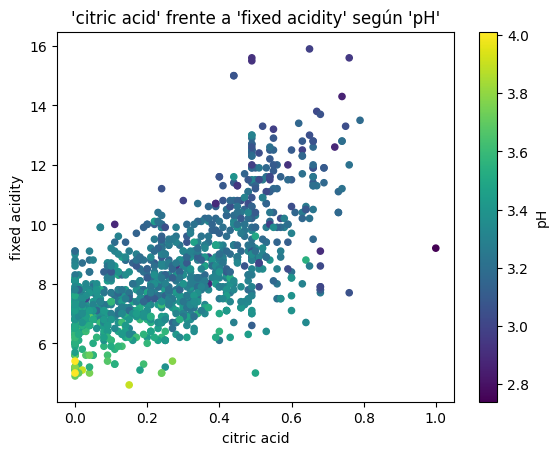

In [6]:
datos.plot.scatter(x="citric acid",y="fixed acidity",c="pH",colormap="viridis", title="'citric acid' frente a 'fixed acidity' según 'pH'")

Los gráficos de cajas y bigotes confirman las sospechas sobre la alta aparición de valores atipícos en múltiples variables a partir de analizar la curtosis, coeficiente de simetría, medidas de tendencia central y dispersión. Hay una elevada cantidad de valores atipícos en los atributos "free sulfur dioxide", "residual sugar", "fixed acidity", "sulphates" y "chlorides". En algunas observamos que la mediana es cercana a la mitad del rectángulo, mientras que en otras vemos que está desplazada a la izquierda lo que concuerda con los hallazgos del coeficiente de simetría.

<Axes: title={'center': 'Gráfico de cajas de los atributos'}>

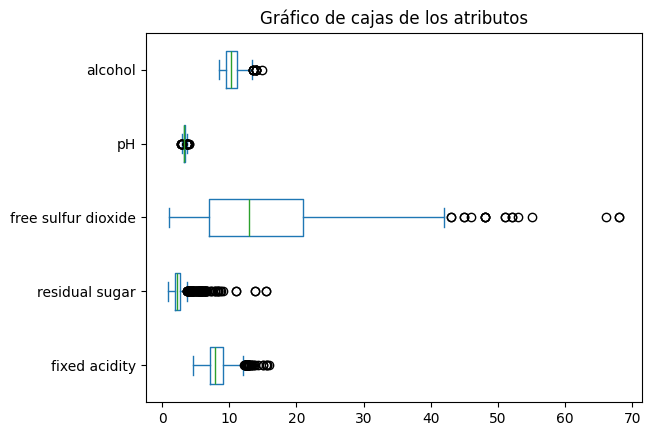

In [7]:
datos.plot.box(column=["fixed acidity", "residual sugar", "free sulfur dioxide", "pH", "alcohol"], vert=False, title="Gráfico de cajas de los atributos")

<Axes: title={'center': 'Gráfico de cajas de los atributos'}>

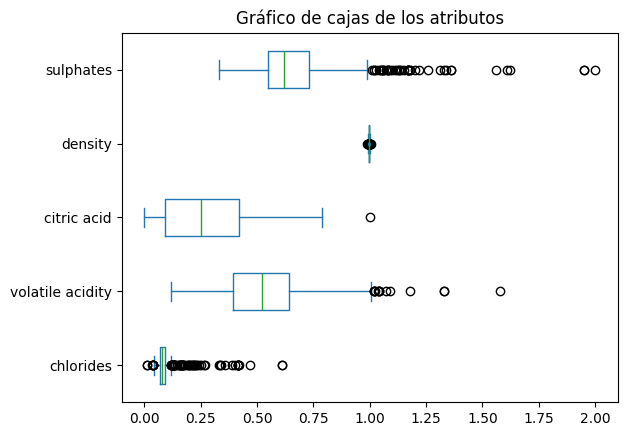

In [20]:
datos.plot.box(column=["chlorides", "volatile acidity", "citric acid","density", "sulphates"], vert=False, title="Gráfico de cajas de los atributos")

Según el gráfico, parece existir una relación entre los atributos "free sulfur dioxide" y "total sulfur dioxide" pues a medida que se incrementa el valor de uno, el otro también aumenta, sin embargo, esto comportamiento no parece ser muy fuerte indicando que el nivel de dependencia entre los atributos es débil.

<Axes: xlabel='free sulfur dioxide', ylabel='total sulfur dioxide'>

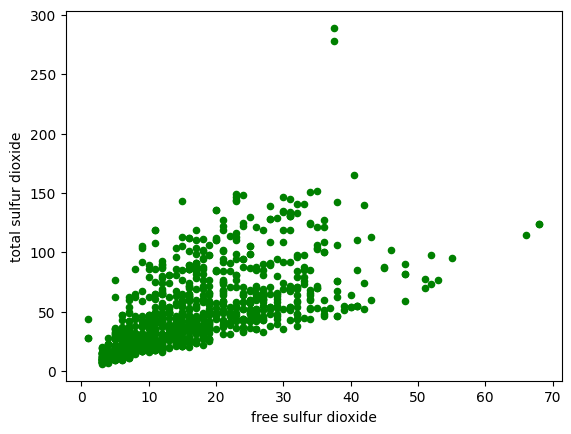

In [21]:
datos.plot.scatter(x="free sulfur dioxide",y="total sulfur dioxide",c="green")

## Variables cualitativas

La única variable cualitativa presente es la etiqueta de clase, el análisis se centra en observar cómo se relaciona con los otros atributos y si hay balance entre la clases. La documentación menciona que son 10 clases según la calidad del vino, sin embargo, solo vemos instancias pertenecientes a 6 de las clases. Además por la gráfica, observamos un amplio desbalance de clases, dónde apróximadamente el 95% de las instancias son vinos de calidad 5, 6 y 7. Habiendo menos de un 2% de instancias de las clases extremas (3 y 8)

| Quality |	Frec. absoluta | Frec. relativa (%) |
| ------- | -------------- | ------------------ |
|5        |	483            |           42.257218|
|6        |	462            |	40.419948       |
|7        |	143            |	12.510936       |
|4        |	33             |	2.887139        |
|8        |	16             |	1.399825        |
|3        |	6              |	0.524934        |

<Axes: title={'center': 'Cantidad de instancias por clase'}, xlabel='quality', ylabel='Cantidad de instancias'>

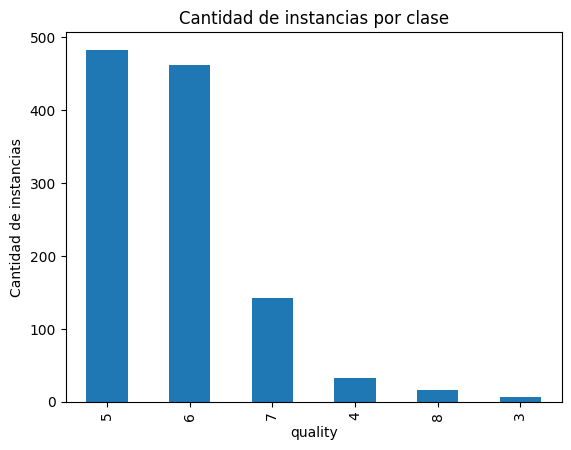

In [8]:
datos["quality"].value_counts().plot.bar(title="Cantidad de instancias por clase",ylabel="Cantidad de instancias")

In [9]:
aux = datos["quality"].value_counts().to_frame(name="Frec. absoluta")

aux["Frec. relativa (%)"] = datos["quality"].value_counts(normalize=True)*100
aux

,Frec. absoluta,Frec. relativa (%)
quality,,
5,483,42.257218
6,462,40.419948
7,143,12.510936
4,33,2.887139
8,16,1.399825
3,6,0.524934


## Análisis de correlación

Dado que los datos no siguen una distribución normal y tampoco se relacionan linealmente, no es adecuado calcular el coeficiente de correlación de Pearson. El coeficiente de Spearman permite medir correlación entre variables que no cumplen estas condiciones y cuya relación es monotóna, además de ser menos sensible a valores atipícos que el coeficiente de Pearson. El coeficiente de Kendall se suele utilizar con muestras pequeñas y cuando se busca una interpretación probabilística.  

En la matriz se encuentran los coeficientes de correlación de Spearman entre cada par de variables. Vemos que según el análisis, los atributos "alcohol" y "pH" están correlacionados con la etiqueta de clase. En el bando contrario, el atributo "volatile acidity" y la etiqueta de clase están inversamente correlacionados.  
En cuanto al resto de variables, vemos que aquellas que describen características de acidez del vino tienen ciertos niveles de correlación como por ejemplo "volatile acidity" y "citric acid" están inversamente correlacionadas. Lo mismo aplica con los atributos "free sulfur dioxide" y "total sulfur dioxide" dónde hay una correlación positiva bastante importante. Otros factores como "residual sugar" y "chlorides" tienen una correlación con el atributo "density".

In [10]:
datos.corr("spearman")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.271597,0.653749,0.242521,0.272554,-0.190341,-0.093900,0.629644,-0.707010,0.194222,-0.085751,0.103887
volatile acidity,-0.271597,1.000000,-0.601305,0.012988,0.153031,0.021178,0.101862,0.019111,0.222106,-0.343500,-0.223379,-0.397784
citric acid,0.653749,-0.601305,1.000000,0.210283,0.142182,-0.075070,0.007291,0.354884,-0.544998,0.340666,0.090691,0.222882
residual sugar,0.242521,0.012988,0.210283,1.000000,0.201531,0.051230,0.124370,0.422578,-0.108683,0.030979,0.123493,0.030614
chlorides,0.272554,0.153031,0.142182,0.201531,1.000000,0.002484,0.126247,0.426509,-0.249068,0.001763,-0.309720,-0.193814
free sulfur dioxide,-0.190341,0.021178,-0.075070,0.051230,0.002484,1.000000,0.793745,-0.071330,0.113952,0.028295,-0.064219,-0.059213
total sulfur dioxide,-0.093900,0.101862,0.007291,0.124370,0.126247,0.793745,1.000000,0.109786,-0.001788,-0.010544,-0.243461,-0.194570
density,0.629644,0.019111,0.354884,0.422578,0.426509,-0.071330,0.109786,1.000000,-0.316985,0.154057,-0.471354,-0.176505
pH,-0.707010,0.222106,-0.544998,-0.108683,-0.249068,0.113952,-0.001788,-0.316985,1.000000,-0.063352,0.195499,-0.033205
sulphates,0.194222,-0.343500,0.340666,0.030979,0.001763,0.028295,-0.010544,0.154057,-0.063352,1.000000,0.198741,0.393681


<Axes: title={'center': "'quality' frente a 'alcohol' según 'sulphates'"}, xlabel='quality', ylabel='alcohol'>

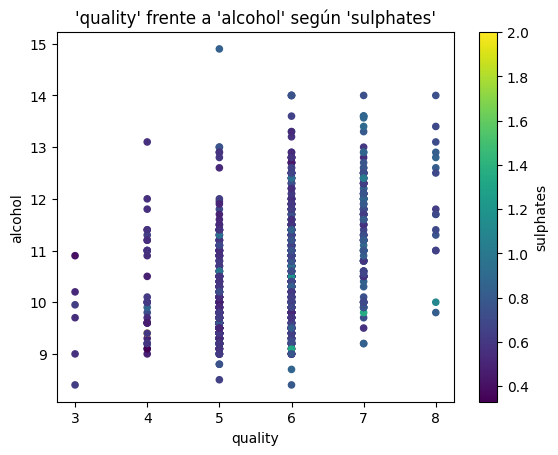

In [11]:
datos.plot.scatter(x="quality", y="alcohol", c="sulphates", colormap="viridis", title="'quality' frente a 'alcohol' según 'sulphates'")

En la gráfica observamos la distribución de valores de los atributos "quality" y "alcohol" relacionados por el atributo "sulphates". Observamos la tendencia ascendente que describe el coeficiente de correlación. Entre más calidad tiene el vino, el nivel de alcohol promedio es superior. De igual forma vemos que a medida que estas 2 variables aumentan de valor, la variable "sulphates" también.

In [12]:
print("Valor promedio de las variables 'alcohol' y 'sulphates' según la calidad del vino.")
datos.groupby("quality")[["alcohol","sulphates"]].mean()

Valor promedio de las variables 'alcohol' y 'sulphates' según la calidad del vino.


,alcohol,sulphates
quality,,
3,9.691667,0.550000
4,10.260606,0.637879
5,9.902277,0.613375
6,10.655339,0.676537
7,11.482634,0.743566
8,11.937500,0.766250


De igual forma, observamos el comportamiento esperado en la variable "volatile acidity" respecto a la etiqueta de clase y el atributo "sulphates". Sin embargo, no ocurre lo mismo con el atributo "alcohol", dónde vemos un coeficiente de correlación bastante bajo por lo que no parece haber correlación entre estas variables.

<Axes: title={'center': "'quality' frente a 'volatile acidity' según 'sulphates'"}, xlabel='quality', ylabel='volatile acidity'>

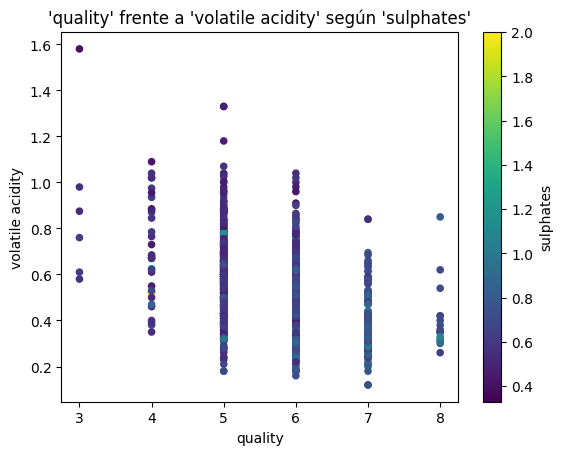

In [13]:
datos.plot.scatter(x="quality", y="volatile acidity", c="sulphates", colormap="viridis", 
                   title="'quality' frente a 'volatile acidity' según 'sulphates'")

# Entrenamiento de modelos
## Feature engineering
Después de entrenar los modelos observamos que los modelos tienen dificultades al clasificar algunas clases de vino, principalmente debido al desbalance excesivo en lsa mismas. Sin embargo, también sabemos que el conjunto de datos posee una gran cantidad de valores atipícos. Esto genera ruido en los modelos y dificultades para que logre aprender patrones ocultos en las instancias. Con el propósito de verificar si tomando los atributos más "relevantes" del conjunto de datos se consigue un desempeño mejor, utilzaremos 2 técnicas de feature engineering:
- Prueba F de ANOVA.
- Coeficiente de información mutua.
  
La recomendación es realizar estos análisis utilizando **solo la partición de entrenamiento** para evitar contaminación causada por los resultados. Sin embargo, en este conjunto de datos el resultado de las pruebas arroja el mismo conjunto de atributos en el caso de la prueba **F de ANOVA**. Para el coeficiente de información mutua, se descarta el atributo `'fixed acidity'` y el resto se mantienen.

**Nota:** Estas técnicas realiza un análisis univariado respecto a la etiqueta de clase por separado. No pueden captar las relaciones entre variables que no son consideradas en la prueba.

In [17]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

columnas = list(datos.columns[:11])
X, y = datos.drop(columns=["quality"]), datos["quality"]

print("Coef. de información mutua")
coef_info_mutua = SelectKBest(f_classif, k=5)
coef_info_mutua.fit(X, y)
print(coef_info_mutua.get_feature_names_out(columnas))

print("\nPrueba F de ANOVA")
f_anova = SelectKBest(mutual_info_classif, k=5)
f_anova.fit(X, y)
print(f_anova.get_feature_names_out(columnas))

Coef. de información mutua
['volatile acidity' 'citric acid' 'total sulfur dioxide' 'sulphates'
 'alcohol']

Prueba F de ANOVA
['fixed acidity' 'volatile acidity' 'total sulfur dioxide' 'sulphates'
 'alcohol']


Tras calcular las puntuaciones de los estadísticos sobre cada atributo respecto al atributo de clase "quality", vemos que en ambos casos se obtuvo el mismo conjunto. La mayoría de atributos que mostraron algún tipo de correlación en la fase de análisis exploratorio están presentes lo que indica que quizá puedan dar un mejor panorama a los modelos.

## Preprocesamiento de datos

Inicialmente, realizamos 2 particiones de nuestro conjunto de datos, una para entrenamiento que conservará el 80% de las instancias y el 20% restante se utilizará para pruebas. Luego, debido a que todas las variables del conjunto de datos son cuantitativas es conveniente normalizar los valores de las mismas para facilitar el entrenamiento de los modelos. Esto es beneficioso en técnicas como redes neuronales y máquinas de soporte vectorial. También debe añadirse un mecanismo para imputar datos faltantes en cualquiera de las columnas, en este caso, se utilizará la mediana de cada atributo. Finalmente solo resta entrenar y ejecutar nuestro pipeline.

In [3]:
import warnings

# Desactivamos las advertencias
warnings.filterwarnings("ignore")

# Desplazamos los valores de las etiquetas de clase para que comiencen desde 0 (algunos modelos arrojan excepciones
# sino se realiza este cambio)
datos["quality"] -= 3

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

# 80% de los datos para entrenamiento y el restante para prueba/validación
X_train, X_test, Y_train, Y_test = train_test_split(datos.drop(columns=["quality"]), datos["quality"], 
                                                    test_size=0.2, train_size=0.8, random_state=123)

# Retiramos la etiqueta de clase de las instancias
# ATRIBS = ['volatile acidity', 'citric acid', 'total sulfur dioxide', 'sulphates', 'alcohol']
# X_train, X_test = X_train[ATRIBS], X_test[ATRIBS]

# Pipeline que se aplica a todas las columnas
pipeline = Pipeline([
    # En caso de haber valores nulos en alguna columna, se rellena con la mediana
    ("rellenado", SimpleImputer(strategy="median")),
    # Se normalizan los valores de cada columna
    ("normalizacion", StandardScaler())
])

pipeline_red_dimensionalidad = Pipeline([
    # Seleccionando los atributos más relevantes
    ("seleccion_atributos", SelectKBest(f_classif, k=5)),
    # En caso de haber valores nulos en alguna columna, se rellena con la mediana
    ("rellenado", SimpleImputer(strategy="median")),
    # Se normalizan los valores de cada columna
    ("normalizacion", StandardScaler())
])

# El normalizador solo se entrena con la partición de entrenamiento para evitar contaminación y cualquier clase
# de sesgo derivado de usar instancias de la partición de prueba
x_train, x_test = pipeline.fit_transform(X_train), pipeline.transform(X_test)
y_train, y_test = Y_train.copy(), Y_test.copy()


x_train_red_dimensionalidad = pipeline_red_dimensionalidad.fit_transform(X_train, Y_train)
x_test_red_dimensionalidad = pipeline_red_dimensionalidad.transform(X_test)

## SMOTE para mitigar el desbalance de clases
Como se evidenció en la fase de entrenamiento y prueba, el desempeño de los clasificadores solo destaca con instancias de las 2 clases con más volumen de instancias. Existen múltiples técnicas para lograr el balanceo de clases que adoptan estrategias de submuestreo o sobremuestreo. La biblioteca `imbalanced-learn` ofrece distintas implementaciones de ambas aproximaciones. Una alternativa que podría sonar atractiva es la técnica SMOTE que genera instancias sintéticas a partir de las instancias ya existentes.  
En este caso la técnica SMOTE no puede aportar mucho a mejorar el desempeño de los modelos debido a que 3 de las 6 clases concentran el 92% de las instancias por lo que las otras 3 clases en conjunto concentran menos de 60 instancias, por lo que SMOTE deberá generar una gran cantidad de instancias a partir de un grupo muy reducido. Sin embargo, veremos que sucede con el desempeño de los modelos si utilizamos esta técnica.

**Nota:** La técnica debe usarse sobre la partición de entrenamiento **y no sobre la partición de pruebas**. Esto evita que instancias sintéticas generadas a partir del mismo grupo de instancias estén presentes en ambos conjuntos y conlleve a un falsa sensación de buen desempeño en los clasificadores.

In [16]:
from imblearn.over_sampling import SMOTE

# Para la generación se deben tomar como máx. 3 instancias base debido a que al particionar los datos para entrenamiento
# y validación, quedan 3 instancias de la clase de menor tamaño.
smote = SMOTE(random_state=123, sampling_strategy="not majority", k_neighbors=3)

# La técnica SMOTE solo debe ser utilizada sobre la partición de entrenamiento
x_train, y_train = smote.fit_resample(X_train, Y_train)

# Se reentrena el normalizador
x_train, x_test = pipeline.fit_transform(DataFrame(x_train, columns=ATRIBS)), pipeline.transform(X_test)

## Métricas
Las métricas en problemas de clasificación se derivan de la matriz de confusión, dado que estos problemas contemplan más de 2 clases es necesario extender la definición de matriz de confusión. Ahora la matriz de confusión tendrá tantas filas y columnas como clases. La estructura de la matriz es la misma, las filas representan la clase verdadera de las instancias y las columnas la clase predicha.
<center>
<img height="200px" width="200px" src="https://media.geeksforgeeks.org/wp-content/uploads/20240708132251/confusion-Matrix.PNG" alt="Multilabel confussion matrix"/>
</center>

- **Verdaderos positivos:** Instancias que son correctamente clasificadas en la clase que se está evaluando. *Ejemplo:* Una instancia que pertenece a la clase B es clasificada correctamente en esa clase.

- **Verdaderos negativos:** Instancias que no pertenecen a la clase que se está evaluando y son clasificadas en una clase distinta a esta. *Ejemplo:* Se está evaluando la clase C y una instancia que no pertenece a esta clase es clasificada en la clase D.

- **Falso positivo:** Instancias que son incorrectamente clasificadas en la clase que se está evaluando. *Ejemplo:* Se está evaluando la clase A y una instancia que pertenece a la clase B es incorrectamente clasificada en la clase A.

- **Falso negativo:** Instancias que son incorrectamente clasificadas en una clase distinta a la que se está evaluando. *Ejemplo:* Se está evaluando la clase B y Una instancia que pertenece a esta clase es incorrectamente clasificada en la clase D.

La única métrica que no cambia la forma en que se calcula es el `accuracy`.

### Recall, precision, F1-score y specificity
Con estas nuevas definiciones, las métricas "recall", "specificity", "f1-score", "precision" y "auc" se obtienen de la siguiente forma:

- **`micro`:** Se calcula la métrica a partir de obtener la cantidad global de valores verdaderos positivos, verdaderos negativos y  falsos positivos y negativos.
- **`macro`:** Se calcula cada métrica para cada clase y luego se obtiene el valor promedio a partir de la métrica de cada clase. No tiene en cuenta problemas por desbalance de clases.
- **`weighted`:** Sigue la misma estrategia 'macro' solo que calcula se calcula un promedio ponderado (multiplicando las métricas de cada clase por el número de instancias que pertenecen a esa clase). Este enfoque si tiene en cuenta el desbalance de clases.

Para implementar esto solo es necesario adicionar el parámetro `average` en la función de `scikit` o `imblearn`, para el "recall" sería: `recall_score(y_true, y_pred, average="micro")`.

### AUC
El AUC es una métrica especial dado que se obtiene a partir la curva ROC y esta a su vez depende de la métricas "specificity" y "recall" que se evaluan a diferentes umbrales de decisión. Al igual que con las otras métricas, el calculo del valor global sigue alguna de las estrategias ya mencionadas ("micro", "macro" y "weighted"). Estas son las 2 variaciones:

- **One vs rest (`ovr`):** Calcula el AUC de una clase frente al resto de clases (el resto de clases no se toma individualmente). En total calculará tantos valores de AUC como clases hayan. También es sensible al desbalance de clases.
- **One vs one (`ovo`):** Se calcula el AUC entre todas las posibles combinaciones de parejas de clases. *Ejemplo:* Si se tienen las clases A,B y C, calculará el AUC entre la clase A y B, B y A, A y C, C y A, etc. No es sensible al desbalance de clases.


Para implementar esto solo es necesario adicionar el parámetro `multi_class` en la función de `roc_auc_score` así: `roc_auc_score(y_true, probs, average="micro", multi_class="ovr")`.

In [13]:
from numpy import ndarray
from imblearn.metrics import specificity_score
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

def entrenar_modelo(
    modelo: BaseEstimator, hiperparametros: dict, x_train: ndarray, y_train: ndarray, 
    metricas: str|list[str], kfolds: int, mostrar_metricas: bool = True,
    x_test: ndarray = None, y_test: ndarray = None, average: str = "micro", multiclass: str = "ovr"
) -> dict:
    """
    Entrena un modelo de scikit utilizando la herramiento 'GridSearchCV' para hallar la mejor configuración de
    hiperparámetros sobre el conjunto de entrenamiento utilizado. Para determinar el modelo utiliza validación cruzada.

    Params:
        modelo (BaseEstimator): Modelo de scikit a entrenar. Se sugiere que solo tenga definidos hiperparámetros como fijos
        como "n_jobs" y "random_state".
        hiperparametros (dict): Diccionario de hiperparámetros (claves) con sus respectivos valores a probar (tuplas).
        x_train (ndarray|DataFrame): Datos de entrenamiento (sin etiquetas).
        y_train (ndarray|DataFrame): Etiquetas de los datos de entrenamiento.
        metricas (str|callable|list[str]): Métricas a evaluar en la validación cruzada.
        kfolds (int): Cantidad de particiones a utilizar en la validación cruzada.
        mostrar_metricas (bool): Indicador para calcular métricas del modelo que se obtenga sobre un conjunto de prueba.
        x_test (ndarray|DataFrame): Datos de prueba (sin etiquetas).
        y_test (ndarray|DataFrame): Etiquetas de los datos de prueba.
        average (str): Método que se utilizará para calcular las métricas. Solo se utiliza si "mostrar_metricas" es True. 
        Los valores disponibles son: "micro", "macro", "weighted" e "instances".
        multiclass (str): Método que se utilizará para calcular el AUC. Solo se utiliza si "mostrar_metricas" es True.
        Los valores disponibles son "ovr" y "ovo".

    Returns:
        dict: Diccionario que contiene el modelo hallado por GridSearchCV (clave "modelo"), los hiperparámetros (clave "hiperparametros") y
        el valor de las métricas que obtuvo durante la validación cruzada (clave "metricas").
    """
    BUSCADOR = GridSearchCV(
        modelo,                             # La técnica a explorar (en este caso una SVM de tipo Nu).
        hiperparametros,                    # Diccionario con los hiperparámetros.
        scoring=metricas,                   # Métrica(s) a utilizar para evaluar el modelo.
        n_jobs=-1,                          # Cantidad de núcleos a utilizar para la evaluación (-1 = usar todos).
        refit=True,                         # Indicador para reentrenar el modelo con mejores hiperparámetros usando todo el conjunto de datos.
        cv=kfolds,                          # Cant. de divisiones utilizadas para la validadión cruzada (parámetro "k" de StratifiedKFolds).
    )

    params_fit = {"eval_set": [(x_test, y_test)], "verbose": False} if isinstance(modelo, XGBClassifier) else {}

    # Se inicia el proceso de entrenamiento y exploración de los modelos.
    BUSCADOR.fit(x_train, y_train, **params_fit)
    
    # Una vez finalizado el entrenamiento, se puede obtener la instancia del modelo con el mejor desempeño.
    MEJOR_MODELO = BUSCADOR.best_estimator_
    # También se puede obtener la combinación de hiperparámetros con mejor desempeño (es un diccionario).
    MEJORES_HIPERPARAMETROS = BUSCADOR.best_params_
    # De igual forma se puede ver el valor que obtuvo este modelo sobre la(s) métrica(s) evaluada(s).
    MEJORES_METRICAS = BUSCADOR.best_score_

    if mostrar_metricas:
        y_pred = MEJOR_MODELO.predict(x_test)
        probs = MEJOR_MODELO.predict_proba(x_test)
        print(f"Accuracy: {(accuracy_score(y_test, y_pred)*100):2f}%")
        print(f"AUC ROC ({average}-{multiclass}): {(roc_auc_score(y_test, probs, average=average, multi_class=multiclass)*100):0.2f}%")
        print(f"F1-score ({average}): {(f1_score(y_test, y_pred, average=average)*100):0.2f}%")
        print(f"Recall ({average}): {(recall_score(y_test, y_pred, average=average)*100):0.2f}%")
        print(f"Specificity ({average}): {(specificity_score(y_test, y_pred, average=average)*100):0.2f}%")

    return {"modelo": MEJOR_MODELO, "hiperparametros": MEJORES_HIPERPARAMETROS, "metricas": MEJORES_METRICAS }

## Definición de hiperparámetros

In [9]:
# 80
params_svc = {
    "C": (0.5, 1, 2, 5, 10),
    "kernel": ("sigmoid", "rbf", "poly", "linear"),
    "gamma": ("scale", "auto"),
    "probability": (True, False),
}

# 810
params_arbol = {
    "criterion": ("gini", "entropy", "log_loss"),
    "splitter": ("best", "random"),
    "max_depth": (None, 4, 5, 7, 8, 11),             # Menos atributos (None, 3, 4, 5) - todos (None, 4, 5, 7, 8, 11)
    "max_features": ("sqrt", "log2", None),
    "min_samples_split": (2, 10, 30),
    "min_samples_leaf": (1, 5, 15)
}

# 4860
params_bosque = {
    "n_estimators": (4, 5, 10, 30, 60, 100, 200) ,            # Menos atributos (3, 4, 5, 10) - todos (4, 5, 10, 30, 60, 100, 200) 
    "criterion": ("gini", "entropy", "log_loss"),
    "max_depth": (None, 4, 5, 7, 8, 11),           # Menos atributos (None, 3, 4, 5) - todos (None, 4, 5, 7, 8, 11)
    "max_features": ("sqrt", "log2", None),
    "min_samples_split": (2, 10, 30),
    "min_samples_leaf": (1, 5, 15),
    "bootstrap": (True, False)
}

# 108
params_red_neuronal = {
    "hidden_layer_sizes": ((5, 5, 6), (5, 6), (5,6,5,6), (5,5,5,7,5)), # ((11, 10, 6, 6), (10, 10, 10), (11,10,9,8,7), (11, 10, 9, 10, 11, 6)) todos
    # Menos atributos - ((5, 5, 6), (5, 6), (5,6,5,6), (5,5,5,7,5))
    "solver": ("sgd", "lbfgs", "adam"),
    "activation": ("relu", "tanh", "sigmoid"),
    "learning_rate_init": (1e-3,5e-3,1e-4),    
}

# 180
params_regresion_logistica = {
    "penalty": ("elasticnet", "l2", None),
    "C": (0.5, 0.7, 1, 2, 5),
    "tol": (1e-4, 5e-5, 1e-5),
    "solver": ("lbfgs", "newton-cholesky", "saga", "sag")
}

# 432
params_knn = {
    "n_neighbors": (3, 10, 30, 60, 100, 200),
    "weights": ("uniform", "distance"),
    "algorithm": ("auto", "ball_tree", "kd_tree"),
    "leaf_size": (20, 30, 50, 100),
    "metric": ("minkowski", "manhattan", "euclidean")
}

# 360
params_xgboost_cpu = {
    "n_estimators": (4, 5, 10, 30, 60, 100, 200), # Menos atributos (3, 4, 5, 10) - todos (4, 5, 10, 30, 60, 100, 200)
    "booster": ("dart", "gbtree", "gblinear"),
    "tree_method": ("approx", "hist"),
    "sampling_method": ("uniform",),
    "max_depth": (0, 4, 5, 7, 8, 11),     # Menos atributos (0, 3, 4, 5) - todos (0, 4, 5, 7, 8, 11)
    "eta": (0.1, 0.05, 0.3, 0.7)
}

params_xgboost_gpu = {
    "n_estimators": (4, 5, 10, 30, 60, 100, 200), # Menos atributos (3, 4, 5, 10) - todos (4, 5, 10, 30, 60, 100, 200)
    "booster": ("dart", "gbtree", "gblinear"),
    "tree_method": ("approx", "hist"),
    "sampling_method": ("gradient_based",),
    "max_depth": (0, 4, 5, 7, 8, 11),    # Menos atributos (0, 3, 4, 5) - todos (0, 4, 5, 7, 8, 11)
    "eta": (0.1, 0.05, 0.3, 0.7)
}

TIPO_METRICAS = "weighted"
TIPO_AUC = "ovo"

## Entrenamiento de los modelos
Experimentaremos con las siguientes técnicas:

1. Máquinas de soporte vectorial.
2. Árboles de decisión.
3. Redes neuronales.
4. Árboles extremadamente aleatorios.
5. Bosques aleatorios.
6. XGBoost.
7. KNN.
8. Regresión logística.

Para hallar la configuración "óptima" de hiperparámetros entre los valores enunciados, se utilizará `GridSearchCV` para evaluar el accuracy de cada modelo. Esta utilidad emplea validación cruzada para obtener una mejor perspectiva sobre el desempeño de cada modelo, evadiendo problemas derivados por la utilización de una partición de datos "buena"/conveniente al entrenar los modelos.

In [ ]:
from sklearn.svm import SVC

# Las máquinas de tipo "NuSVM" tienen problemas para adaptarse a los datos debido al excesivo ruido
# SVC = entrenar_modelo(
#     SVC(random_state=123), params_svc, x_train, y_train, "accuracy", 7, True, x_test, y_test, TIPO_METRICAS, TIPO_AUC
# )
# print(SVC["hiperparametros"])

# 67,69% accuracy - auc 78,40% - f1-score 66,47% - recall 67,69% - specificity 79,39%
SVM = SVC(random_state=123, C=5,gamma="auto", kernel="rbf", probability=True)
SVM.fit(x_train, y_train)

# 62,45% accuracy - auc 74,43% - f1-score 64,94% - recall 62,45% - specificity 84,32%
# SVM_SMOTE = SVC(random_state=123, C=10,gamma="scale", kernel="rbf", probability=True)
# SVM_SMOTE.fit(x_train, y_train)

# 62,45% accuracy - auc 76,67% - f1-score 61,17% - recall 62,45% - specificity 73,44%
# SVM_MENOR_DIM = SVC(random_state=123, C=1,gamma="auto", kernel="rbf", probability=True)
# SVM_MENOR_DIM.fit(x_train, y_train)

# 46,29% accuracy - auc 75,51% - f1-score 51,36% - recall 46,29% - specificity 82,76%
# SVM_SMOTE_MENOR_DIM = SVC(random_state=123, C=10,gamma="scale", kernel="rbf", probability=True)
# SVM_SMOTE_MENOR_DIM.fit(x_train, y_train)

In [10]:
from sklearn.tree import DecisionTreeClassifier

# ARBOL = entrenar_modelo(
#     DecisionTreeClassifier(random_state=123), params_arbol, x_train, y_train, "accuracy", 7, True, x_test, y_test,
#     TIPO_METRICAS, TIPO_AUC
# )

# print(ARBOL["hiperparametros"])

# 54,15% accuracy - auc 69,68% - f1-score 53,32% - recall 54,15% - specificity 69,56%
# ARBOL = DecisionTreeClassifier(random_state=123,criterion="entropy", max_depth=5, max_features="sqrt",min_samples_leaf=1,
#                                          min_samples_split=10, splitter="best")
# ARBOL.fit(x_train, y_train)

# 55,02% accuracy - auc 61,80% - f1-score 57,51% - recall 55,02% - specificity 80,81%
# ARBOL_SMOTE = DecisionTreeClassifier(random_state=123,criterion="gini",max_depth=None, max_features="sqrt",min_samples_leaf=1,
#                                      min_samples_split=2, splitter="best")
# ARBOL_SMOTE.fit(x_train, y_train)

# 57,21% accuracy - auc 62,29% - f1-score 55,42% - recall 57,21% - specificity 69,07%
ARBOL_MENOR_DIM = DecisionTreeClassifier(random_state=123,criterion="gini", max_depth=None, max_features="sqrt",min_samples_leaf=1,
                                         min_samples_split=30, splitter="best")
ARBOL_MENOR_DIM.fit(x_train_red_dimensionalidad, y_train)

# 53,71% accuracy - auc 62,62% - f1-score 56,39% - recall 53,71% - specificity 80,87%
# ARBOL_SMOTE_MENOR_DIM = DecisionTreeClassifier(random_state=123,criterion="gini",max_depth=None,max_features=None,min_samples_leaf=1,
#                                                min_samples_split=2, splitter="best")
# ARBOL_SMOTE_MENOR_DIM.fit(x_train, y_train)

DecisionTreeClassifier(max_features='sqrt', min_samples_split=30,
                       random_state=123)

In [27]:
from sklearn.ensemble import RandomForestClassifier

# BOSQUE = entrenar_modelo(
#     RandomForestClassifier(random_state=123, n_jobs=-1), params_bosque, x_train, y_train, "accuracy", 7, True, x_test,
#     y_test, TIPO_METRICAS, TIPO_AUC
# )

# print(BOSQUE["hiperparametros"])

# 71,18% accuracy - auc 77,47% - f1-score 70,04% - recall 71,18% - specificity 81,30%
BOSQUE = RandomForestClassifier(random_state=123, n_jobs=-1, bootstrap=True, criterion="gini", max_features="sqrt", min_samples_leaf=1,
                                max_depth=11, min_samples_split=2, n_estimators=200)
BOSQUE.fit(x_train, y_train)

# % accuracy - auc % - f1-score % - recall % - specificity %
# BOSQUE_SMOTE = RandomForestClassifier(random_state=123, n_jobs=-1, bootstrap=True, criterion="gini", max_features="sqrt", min_samples_leaf=1,
#                                       min_samples_split=2, n_estimators=200)
# BOSQUE_SMOTE.fit(x_train, y_train)

# 65,94% accuracy - auc 72,23% - f1-score 64,92% - recall 65,94% - specificity 78,02%
# BOSQUE_MENOR_DIM = RandomForestClassifier(random_state=123, n_jobs=-1, bootstrap=False, criterion="gini", max_features="sqrt",
#                                           max_depth=None, min_samples_leaf=1, min_samples_split=10, n_estimators=10)
# BOSQUE_MENOR_DIM.fit(x_train, y_train)

# 58,08% accuracy - auc 75,59% - f1-score 60,33% - recall 58,08% - specificity 82,34%
# BOSQUE_SMOTE_MENOR_DIM = RandomForestClassifier(random_state=123, n_jobs=-1, bootstrap=False, criterion="entropy", max_features="sqrt",
#                                                 max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=10)
# BOSQUE_SMOTE_MENOR_DIM.fit(x_train, y_train)

RandomForestClassifier(max_depth=11, n_estimators=200, n_jobs=-1,
                       random_state=123)

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

# EXTRATREES = entrenar_modelo(
#     ExtraTreesClassifier(random_state=123, n_jobs=-1), params_bosque, x_train, y_train, "accuracy", 7, True, x_test,
#     y_test, TIPO_METRICAS, TIPO_AUC
# )

# print(EXTRATREES["hiperparametros"])

# 70,31% accuracy - auc 80,41% - f1-score 69,36% - recall 70,31% - specificity 81,24%
EXTRATREES =  ExtraTreesClassifier(random_state=123, n_jobs=-1, bootstrap=False, criterion="entropy", max_depth=None, max_features=None,
                                   min_samples-leaf=1, min_samples_split=2, n_estimators=60)
EXTRATREES.fit(x_train, y_train)

# % accuracy - auc % - f1-score % - recall % - specificity %
# EXTRATREES_SMOTE =  ExtraTreesClassifier(random_state=123, n_jobs=-1, bootstrap=False, criterion="entropy", max_depth=None, 
#                                          min_samples-leaf=1, min_samples_split=2, n_estimators=60)
# EXTRATREES_SMOTE.fit(x_train, y_train)

# 64,63% accuracy - auc 69,76% - f1-score 63,65% - recall 64,63% - specificity 78,43%
# EXTRATREES_MENOR_DIM =  ExtraTreesClassifier(random_state=123, n_jobs=-1, bootstrap=False, criterion="entropy", max_features="sqrt",
#                                              max_depth=None, min_samples-leaf=1, min_samples_split=2, n_estimators=10)
# EXTRATREES_MENOR_DIM.fit(x_train, y_train)

# 56,33% accuracy - auc 78,21% - f1-score 57,90% - recall 56,33% - specificity 82,62%
# EXTRATREES_SMOTE_MENOR_DIM =  ExtraTreesClassifier(random_state=123, n_jobs=-1, bootstrap=False, criterion="entropy", max_features="sqrt",
#                                                    max_depth=None, min_samples-leaf=1, min_samples_split=2, n_estimators=10)
# EXTRATREES_SMOTE_MENOR_DIM.fit(x_train, y_train)

In [ ]:
from sklearn.neural_network import MLPClassifier

# RED_NEURONAL = entrenar_modelo(
#     MLPClassifier(random_state=123, early_stopping=True, validation_fraction=0.1), params_red_neuronal, x_train,
#     y_train, "accuracy", 7, True, x_test, y_test, TIPO_METRICAS, TIPO_AUC
# )

# print(RED_NEURONAL["hiperparametros"])

# 62,01% accuracy - auc 61,99% - f1-score 57,31% - recall 62,01% - specificity 70,76%
# RED_NEURONAL_ = MLPClassifier(random_state=123, early_stopping=True, validation_fraction=0.1, activation="relu", solver="adam",
#                              hidden_layer_sizes=(11, 10, 9, 10, 11, 6), learning_rate_init=5e-3)
# RED_NEURONAL.fit(x_train, y_train)

# 31,00% accuracy - auc 57,92% - f1-score 27,76% - recall 31,00% - specificity 71,08%
# RED_NEURONAL_SMOTE = MLPClassifier(random_state=123, early_stopping=True, validation_fraction=0.1, activation="tanh", solver="lbfgs",
#                                    hidden_layer_sizes=(10,10,10), learning_rate_init=1e-3)
# RED_NEURONAL_SMOTE.fit(x_train, y_train)

# 63,32% accuracy - auc 71,05% - f1-score 62,19% - recall 63,32% - specificity 74,33%
RED_NEURONAL_MENOR_DIM = MLPClassifier(random_state=123, early_stopping=True, validation_fraction=0.1, activation="relu", solver="lbfgs",
                                       hidden_layer_sizes=(5, 5, 5, 7, 5), learning_rate_init=1e-3)
RED_NEURONAL_MENOR_DIM.fit(x_train_red_dimensionalidad, y_train)

# 39,74% accuracy - auc 74,64% - f1-score 44,71% - recall 39,74% - specificity 82,70%
# RED_NEURONAL_SMOTE_MENOR_DIM = MLPClassifier(random_state=123, early_stopping=True, validation_fraction=0.1, activation="tanh",
#                                              solver="lbfgs", hidden_layer_sizes=(5,6,5,6), learning_rate_init=1e-3)
# RED_NEURONAL_SMOTE_MENOR_DIM.fit(x_train, y_train)

In [ ]:
from sklearn.linear_model import LogisticRegression

# REGRESION_LOGISTICA = entrenar_modelo(
#     LogisticRegression(random_state=123), params_regresion_logistica, x_train, y_train, "accuracy", 7, True,
#     x_test, y_test, TIPO_METRICAS, TIPO_AUC
# )
# print(REGRESION_LOGISTICA["hiperparametros"])

# 62,45% accuracy - auc 75,10% - f1-score 61,25% - recall 62,45% - specificity 74,62%
REG_LOGISTICA = LogisticRegression(random_state=123, C=2, penalty="l2", solver="lbfgs", tol=1e-4)
REG_LOGISTICA.fit(x_train_red_dimensionalidad, y_train)

# 40,61% accuracy - auc 71,42% - f1-score 47,24% - recall 40,61% - specificity 84,88%
# REG_LOGISTICA_SMOTE = LogisticRegression(random_state=123, C0.5, penalty=None, solver="sag", tol=1e-4)
# REG_LOGISTICA_SMOTE.fit(x_train, y_train)

# 62,45% accuracy - auc 75,10% - f1-score 61,25% - recall 62,45% - specificity 74,62%
# REG_LOGISTICA_MENOR_DIM = LogisticRegression(random_state=123, C=2, penalty="l2", solver="lbfgs", tol=1e-4)
# REG_LOGISTICA_MENOR_DIM.fit(x_train, y_train)

# 37,99% accuracy - auc 73,75% - f1-score 45,44% - recall 37,99% - specificity 84,83%
# REG_LOGISTICA_SMOTE_MENOR_DIM = LogisticRegression(random_state=123, C=2, penalty="l2", solver="lbfgs", tol=1e-4)
# REG_LOGISTICA_SMOTE_MENOR_DIM.fit(x_train, y_train)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# KNN = entrenar_modelo(
#     KNeighborsClassifier(n_jobs=-1), params_knn, x_train, y_train, "accuracy", 7, True, x_test,
#     y_test, TIPO_METRICAS, TIPO_AUC
# )
# print(KNN["hiperparametros"])

# 69,00% accuracy - auc 83,90% - f1-score 67,78% - recall 69,00% - specificity 78,56%
KNN = KNeighborsClassifier(n_jobs=-1, algorithm="auto", leaf_size=20, metric="manhattan", n_neighbors=100, weights="distance")
KNN.fit(x_train, y_train)

# 55,02% accuracy - auc 66,60% - f1-score 57,64% - recall 55,02% - specificity 83,18%
# KNN_SMOTE = KNeighborsClassifier(n_jobs=-1, algorithm="auto", leaf_size=20, metric="manhattan", n_neighbors=3, weights="distance")
# KNN_SMOTE.fit(x_train, y_train)

# 69,00% accuracy - auc 83,90% - f1-score 67,78% - recall 69,00% - specificity 78,56%
# KNN_MENOR_DIM = KNeighborsClassifier(n_jobs=-1, algorithm="auto", leaf_size=20, metric="manhattan", n_neighbors=100, weights="distance")
# KNN_MENOR_DIM.fit(x_train, y_train)

# 55,46% accuracy - auc 71,88% - f1-score 58,51% - recall 55,46% - specificity 84,27%
# KNN_MENOR_DIM_SMOTE = KNeighborsClassifier(n_jobs=-1, algorithm="auto", leaf_size=20, metric="manhattan", n_neighbors=3, weights="distance")
# KNN_MENOR_DIM_SMOTE.fit(x_train, y_train)

In [ ]:
from xgboost import XGBClassifier

# XGBOOST_CPU = entrenar_modelo(
#     XGBClassifier(
#         device="cpu", verbosity=0,
#         random_state=123, n_jobs=-1, early_stopping_rounds=5, objective="multi:softmax", eval_metric=accuracy_score
#     ),
#     params_xgboost_cpu, x_train, y_train, "accuracy", 7, True, x_test, y_test, TIPO_METRICAS, TIPO_AUC
# )
# print(XGBOOST_CPU["hiperparametros"])


# XGBOOST_GPU = entrenar_modelo(
#     XGBClassifier(
#         device="cuda", verbosity=0,
#         random_state=123, n_jobs=-1, early_stopping_rounds=5, objective="multi:softmax", eval_metric=accuracy_score
#     ),
#     params_xgboost_gpu, x_train, y_train, "accuracy", 7, True, x_test, y_test, TIPO_METRICAS, TIPO_AUC
# )
# print(XGBOOST_GPU["hiperparametros"])

# 62,45% accuracy - auc 61,94% - f1-score 61,47% - recall 62,45% - specificity 74,70%
XGBOOST = XGBClassifier(random_state=123, booster="dart", n_estimators=4, sampling_method="gradient_based", max_depth=8,
                         tree_method="approx", device="cuda", eta=0.3)
XGBOOST_MENOR_DIM.fit(x_train_red_dimensionalidad, y_train)

# 60,26% accuracy - auc 61,58% - f1-score 59,23% - recall 60,26% - specificity 72,75%
# XGBOOST_SMOTE = XGBClassifier(random_state=123, booster="dart", n_estimators=4, sampling_method="uniform",
#                               max_depth=11, tree_method="approx", device="cpu", eta=0.3)
# XGBOOST_SMOTE.fit(x_train, y_train)

# 58,52% accuracy - auc 64,41% - f1-score 57,31% - recall 58,52% - specificity 71,02%
# XGBOOST_MENOR_DIM = XGBClassifier(random_state=123, booster="dart", n_estimators=10, sampling_method="gradient_based", max_depth=8,
#                                   tree_method="approx", device="cuda", eta=0.3)
# XGBOOST_MENOR_DIM.fit(x_train, y_train)

# 48,47% accuracy - auc 65,73% - f1-score 52,18% - recall 48,47% - specificity 79,56%
# XGBOOST_SMOTE_MENOR_DIM = XGBClassifier(random_state=123, booster="dart", n_estimators=10, sampling_method="gradient_based",
#                                         max_depth=11, tree_method="hist", device="cuda", eta=0.05)
# XGBOOST_SMOTE_MENOR_DIM.fit(x_train, y_train)

## Resultados

En la siguiente tabla se presentan los resultados del entrenamiento y prueba del mejor modelo por cada técnica. Como podemos observar en todos los casos los modelos corresponden a la variante que no utiliza la técnica SMOTE. Esto se debe a que 2 de las clases concentran alrededor del 82% de las instancias, lo que conlleva a que la generación de instancias sintéticas no sea tan fructífera debido al bajo volumen en las 4 clases restantes. Por otro lado también se percibe que utilizar feature engineering para determinar los atributos más relevantes logra un desempeño similar o en ocasiones superior a la contraparte entrenada con la totalidad de los atributos.

| Técnica | Tipo modelo | Accuracy (%) | AUC (%) | F1-Score (%) | Recall (%) | Specificity (%) |
| ------- | ----------- |:------------:|:-------:|:------------:|:----------:|:---------------:|
| Bosques aleatorios | Sin reducción de dimensionalidad | 71,18 | 77,47 | 70,04 | 71,18 | 81,30 |
| Árboles extremadamente aleatorios | Sin reducción de dimensionalidad | 70,31 | 80,41 | 69,36 | 70,31 | 81,24 |
| KNN | Con/sin reducción de dimensionalidad | 69,00 | 83,90 | 67,78 | 69,00 | 78,56 |
| Máquinas de soporte vectorial | Sin reducción de dimensionalidad | 67,69 | 78,40 | 66,47 | 67,69 | 79,39 |
| Red neuronal | Con reducción de dimensionalidad | 63,32 | 71,05 | 62,19 | 63,32 | 74,33 |
| XGBoost | Con reducción de dimensionalidad | 62,45 | 61,94 | 61,47 | 62,45 | 74,70 |
| Reg. logística | Con/sin reducción de dimensionalidad | 62,45 | 75,10 | 61,25 | 62,45 | 74,62 |
| Árboles de decisión | Con reducción de dimensionalidad | 57,21 | 62,29 | 55,42 | 57,21 | 69,07 |

En cuanto de desempeño, el modelo con mejores métricas es el de bosques aleatorios, dónde ninguna de las métricas es inferior a 70%, la diferencia de accuracy respecto al modelo de árboles extremadamente aleatorios es baja y otras métricas como la especificidad. En general los valores de F1-Score son bajos, indicando una poca capacidad de estos modelos para clasificar correctamente las instancias. El valor de la métrica recall es igual al de la métrica accuracy, producto de utilizar la estrategia "one vs. one" dado que estamos revisando de forma individual los aciertos del modelo al clasificar instancias de una clase respecto a otra. Además, la métrica de especificidad resulta superior en todos los modelos, indicandonos que el modelo clasificar mejor cuando una instancia no pertenece a una clase. Sin embargo, esto se produce por el desbalance de clases al tener un volumen de instancias superior de las clases mayoritarias, a los clasificadores les resulta más sencillo encontrar patrones que indiquen la pertenencia a las mismas lo que permite rapidamente descartar instancias de otras clases. Finalmente, aunque la métrica AUC muestra que la capacidad para distinguir entre clases por parte de los modelos es bastante regular.

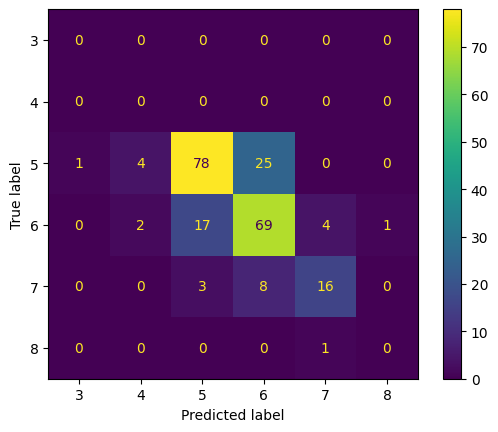

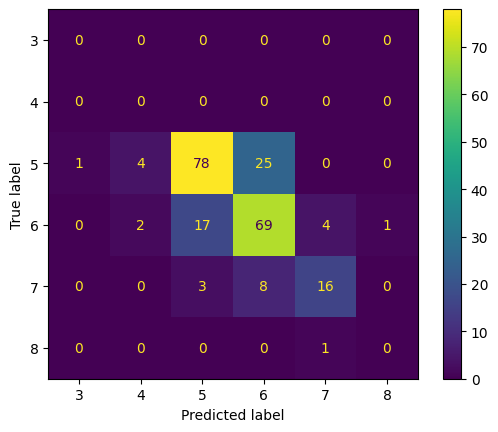

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = BOSQUE.predict(x_test)
matriz = ConfusionMatrixDisplay.from_predictions(y_pred, y_test, display_labels=[f"{i}" for i in range(3,9)])
matriz.plot()

La matriz de confusión nos muestra lo que sospechabamos, el modelo tiene un desempeño bueno clasificando instancias de las 2 clases con mayor volumen de instancias pero con las otras el desempeño es inferior. También resalta el hecho de que en la partición de pruebas no existan instancias de las clases **3**,**4** y de la clase **8** solo haya una instancias.

# Conclusión
Dado el elevado desbalance, gran cantidad de valores atipícos y la gran cantidad de clases, no es posible entrenar un clasificador que obtenga resultados con un accuracy superior al 90%. Utilizar técnicas como SMOTE no son una buena alternativa debido al bajo volumen de instancias en algunas clase dónde como se observó, solo se consigue añadir ruido al modelo y empeorar su rendimiento en muchas ocasiones. Quizá un enfoque mixto (utilizando submuestreo y sobremuestreo) pueda obtener mejores resultados, sin embargo, con el bajo volumen de instancias en algunas clases es díficil.  
Una posible solución es entrenar un clasificador sobre las 3 clases que concentran el 92% de las instancias y utilizar un modelos para detección de anomalías (outliners) como "isolation forests" sobre las clases con menor volumen de instancias (**3**, **4** y **8**). Para finalizar, se debe resaltar el buen desempeño que mostraron los modelos entrenados con reducción de dimensionalidad (feature engineering) siendo en la mayoría de las técnicas, los modelos con mejores resultados. Aunque el conjunto de datos no es de alta dimensionalidad es destacable que con menos de la mitad de los atributos se pueda igualar o incluso superar el desempeño de los modelos entrenados con la totalidad de atributos.